In [1]:
from random import random

import pandas as pd
import numpy as np
import seaborn as sns

In [7]:
file_path = "data/Otodom_Flat_Listings.csv"
df = pd.read_csv(file_path)

## Zadanie 1

In [9]:
print(f"Wartosci większe od 0 dla cechy Price {np.sum(otodom_flats.Price.apply(lambda x:  x > 0))/ df.shape[0]*100:.2f} %")

Wartosci większe od 0 dla cechy Price 94.91 %


In [10]:
for feature in df.columns:
    print(f"Kompletność dla {feature} wynosi : {(1- (np.sum(df[feature].isna()) / df.shape[0])) *100:.2f} %")

Kompletność dla Title wynosi : 100.00 %
Kompletność dla Price wynosi : 94.91 %
Kompletność dla Location wynosi : 99.96 %
Kompletność dla Surface wynosi : 100.00 %
Kompletność dla Number_of_Rooms wynosi : 100.00 %
Kompletność dla Floor wynosi : 97.72 %
Kompletność dla Finishing_Condition wynosi : 79.41 %
Kompletność dla Heating wynosi : 73.39 %
Kompletność dla Parking_Space wynosi : 52.65 %
Kompletność dla Balcony_Garden_Terrace wynosi : 74.88 %
Kompletność dla Link wynosi : 100.00 %
Kompletność dla Voivodeship wynosi : 99.96 %
Kompletność dla City wynosi : 99.96 %


In [11]:
otodom_flats_map = df.isna()
completness = 1 - (np.sum(otodom_flats_map.values) / (otodom_flats_map.shape[0] * otodom_flats_map.shape[1]))
print(f"Dane są kompletne w {completness *100:.2f} %")

Dane są kompletne w 90.22 %


## Zadanie 2

In [12]:
df_cleaned = otodom_flats.dropna(subset=["Price"])
df_cleaned['Price'] = pd.to_numeric(df_cleaned['Price'], errors='coerce')
df_cleaned['Price'].dtype

dtype('float64')

## Histogram cechy Price dla całej populacji

<Axes: ylabel='Frequency'>

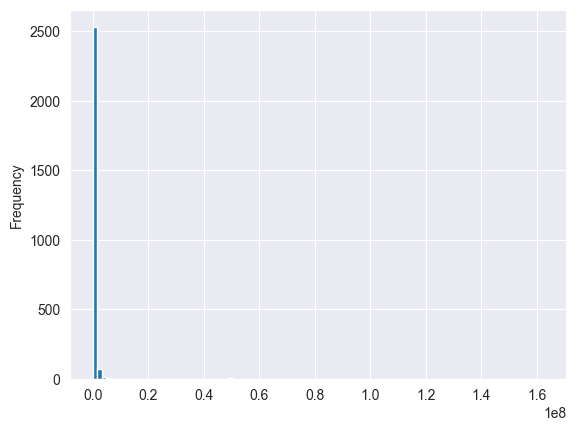

In [21]:
df_cleaned['Price'].plot.hist(bins = 100)

## Histogram cechy Price dla próbki ograniczonej od góry do 10 milionów

<Axes: >

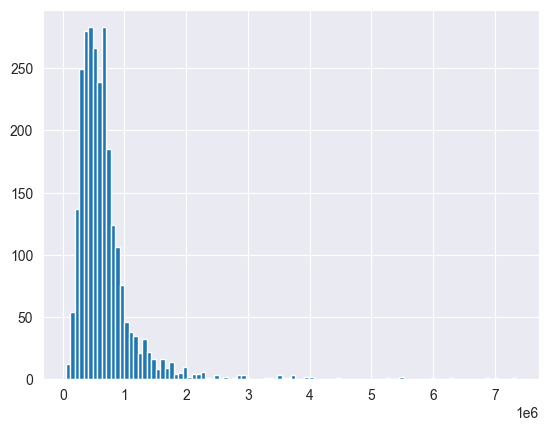

In [24]:
df_cleaned[df_cleaned['Price'] < 10_000_000]['Price'].hist(bins=100)

## Histogram cechy Price dla próbki ograniczonej od góry do 5 milionów

<Axes: >

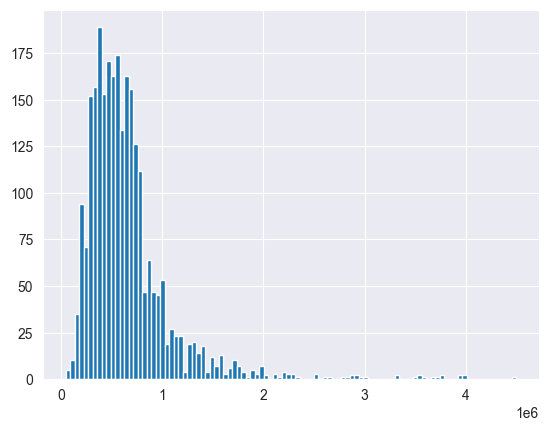

In [25]:
df_cleaned[df_cleaned['Price'] < 5_000_000]['Price'].hist(bins=100)

## Histogram cechy Price dla próbki ograniczonej od góry do 2 milionów

<Axes: >

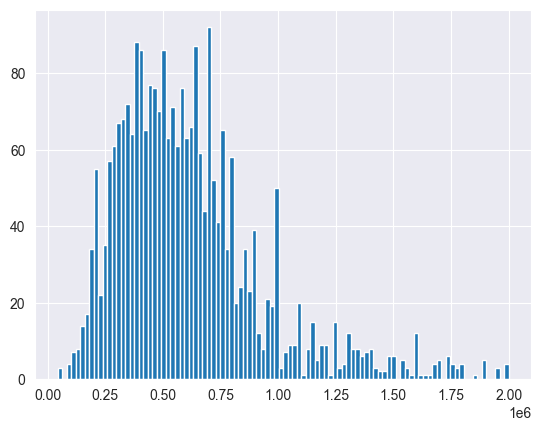

In [26]:
df_cleaned[df_cleaned['Price'] < 2_000_000]['Price'].hist(bins=100)

## Histogram cechy Price dla próbki ograniczonej od góry do 1 milionów

<Axes: >

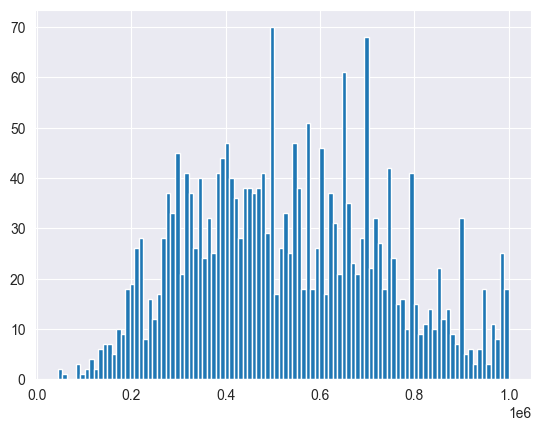

In [27]:
df_cleaned[df_cleaned['Price'] < 1_000_000]['Price'].hist(bins=100)

In [16]:
df_cleaned['Price'].describe

<bound method NDFrame.describe of 0        415000.0
1       2499000.0
2        649000.0
3       2108000.0
4        450180.0
          ...    
2802     525000.0
2803     829000.0
2804     830000.0
2805     699000.0
2806    1450000.0
Name: Price, Length: 2664, dtype: float64>

## Zadanie 3

<Axes: ylabel='Price'>

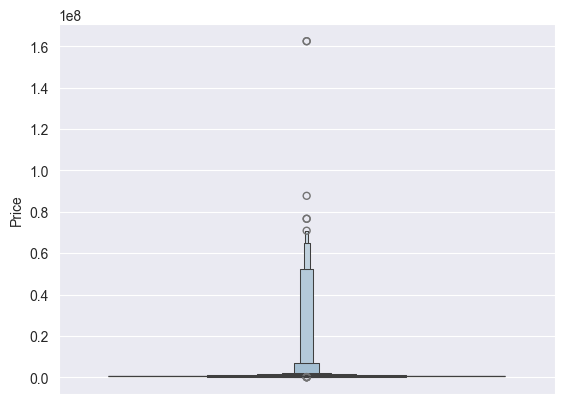

In [28]:
sns.boxenplot(df_cleaned['Price'])

In [34]:
Q1 = df_cleaned['Price'].quantile(0.25)
Q3 = df_cleaned['Price'].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outlier_data = df_cleaned[(df_cleaned['Price'] < lower_bound) | (df_cleaned['Price'] > upper_bound)]
df_filtred_data = df_cleaned[(df_cleaned['Price'] >= lower_bound) & (df_cleaned['Price'] <= upper_bound)]

<Axes: ylabel='Price'>

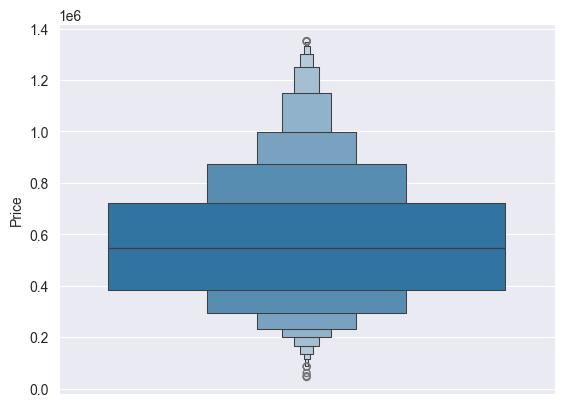

In [35]:
sns.boxenplot(df_filtred_data['Price'])

## Zadanie 4

In [36]:
df['Surface'].dtype

dtype('float64')

In [41]:
df_filtred_data['price_per_m2'] = df_filtred_data['Price'] / df_filtred_data['Surface']

## Histogram cechy price_per_m2

<Axes: xlabel='price_per_m2', ylabel='Count'>

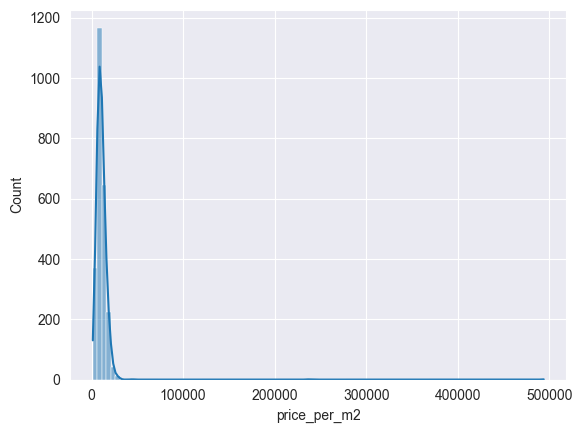

In [45]:
sns.histplot(df_filtred_data['price_per_m2'],kde=True)

<Axes: xlabel='price_per_m2', ylabel='Count'>

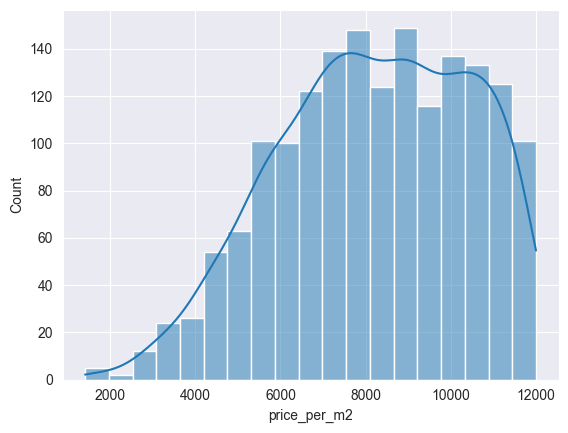

In [48]:
data_subset = df_filtred_data[df_filtred_data['price_per_m2'] < 12000]
sns.histplot(data_subset['price_per_m2'], kde=True)

## Kwartyle

In [50]:
quartiles =  df_filtred_data['price_per_m2'].quantile([0.25, 0.5, 0.75])

In [51]:
print(quartiles)

0.25     7409.930523
0.50     9968.385642
0.75    12910.116633
Name: price_per_m2, dtype: float64


## Zadanie 5

In [66]:
import math
import matplotlib.pyplot as plt
def p_dwumianowe(n, k, p):
    symbol_newtona = math.comb(n, k)
    prawdopodobienstwo = symbol_newtona * (p**k) * ((1-p)**(n-k))
    return prawdopodobienstwo

In [60]:
n = 20
p = 0.5
k = 7
wynik = p_dwumianowe(n,k,p)

In [62]:
dane = []
for k in range(n + 1):
    prob = p_dwumianowe(n, k, p)
    dane.append({'Liczba_Orlow': k, 'Prawdopodobienstwo': prob})

In [63]:
df_coin = pd.DataFrame(dane)

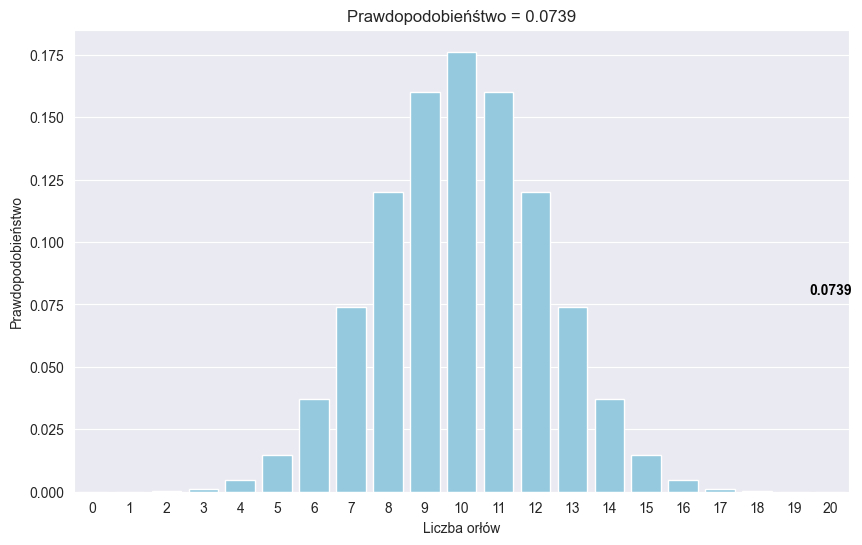

In [73]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_coin, x='Liczba_Orlow', y='Prawdopodobienstwo', color='skyblue')
plt.text(k, wynik + 0.005, f'{wynik:.4f}', color='black', ha="center", weight='bold')
# Dodatkowo, aby zaznaczyć słupek dla k=7 na pomarańczowo (pominąłem dla prostoty)
plt.title(f'Prawdopodobieńśtwo = {wynik:.4f}')
plt.ylabel('Prawdopodobieństwo')
plt.xlabel('Liczba orłów')
plt.show()

## Zadanie 6

In [74]:
def rzuty_kostka(liczba_eksperymentow, liczba_kostek):
    rzuty = np.random.randint(1,7,size = (liczba_eksperymentow,liczba_kostek))
    wynik = rzuty.sum(axis=1)
    return wynik

In [79]:
wyniki_1 = rzuty_kostka(1000, 1)

wyniki_2 = rzuty_kostka(1000, 2)

wyniki_10 = rzuty_kostka(1000, 10)

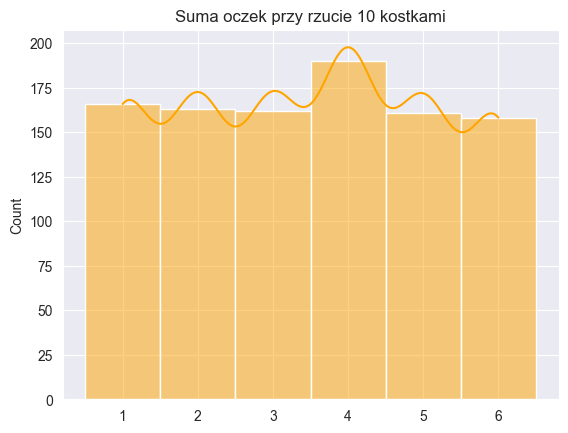

In [81]:
sns.histplot(wyniki_1, kde=True, discrete=True, color='orange')
plt.title("Suma oczek przy rzucie 1 kostka")
plt.show()

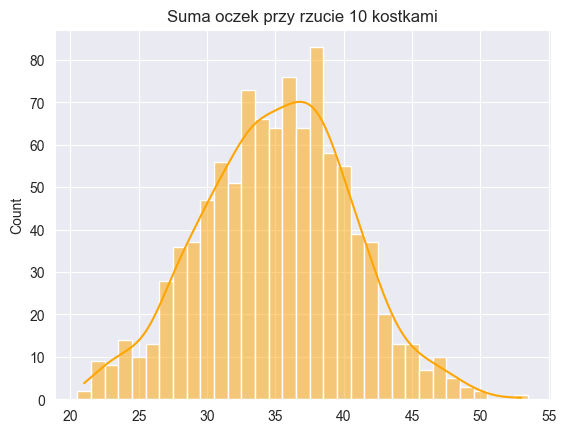

In [82]:
sns.histplot(wyniki_10, kde=True, discrete=True, color='orange')
plt.title("Suma oczek przy rzucie 10 kostkami")
plt.show()

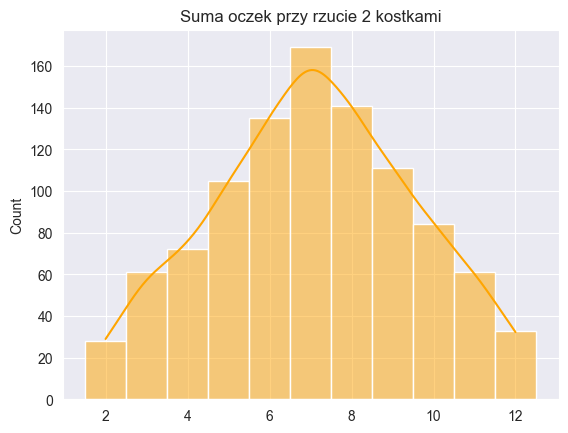

In [83]:
sns.histplot(wyniki_2, kde=True, discrete=True, color='orange')
plt.title("Suma oczek przy rzucie 2 kostkami")
plt.show()